In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_loc = 'https://github.com/dknife/ML/raw/main/data/'
life = pd.read_csv(data_loc + 'life_expectancy.csv')
life.head()

,Country,Year,Status,Life expectancy,Adult mortality,Infant deaths,Alcohol,Percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,Thinness 1-19 years,Thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [47]:
life = life[[
    'Life expectancy', 
    'Year',
    'Alcohol', 
    'Percentage expenditure', 
    'Total expenditure',
    'Hepatitis B', 
    'Measles', 
    'Polio',
    'BMI',
    'GDP',
    'Thinness 1-19 years',
    'Thinness 5-9 years',
]]

print(life)

      Life expectancy  Year  Alcohol  Percentage expenditure  \
0                65.0  2015     0.01               71.279624   
1                59.9  2014     0.01               73.523582   
2                59.9  2013     0.01               73.219243   
3                59.5  2012     0.01               78.184215   
4                59.2  2011     0.01                7.097109   
...               ...   ...      ...                     ...   
2933             44.3  2004     4.36                0.000000   
2934             44.5  2003     4.06                0.000000   
2935             44.8  2002     4.43                0.000000   
2936             45.3  2001     1.72                0.000000   
2937             46.0  2000     1.68                0.000000   

      Total expenditure  Hepatitis B  Measles  Polio   BMI         GDP  \
0                  8.16         65.0     1154    6.0  19.1  584.259210   
1                  8.18         62.0      492   58.0  18.6  612.696514   
2        

In [48]:
print(life.shape)
print(life.isnull().sum())

(2938, 12)
Life expectancy            10
Year                        0
Alcohol                   194
Percentage expenditure      0
Total expenditure         226
Hepatitis B               553
Measles                     0
Polio                      19
BMI                        34
GDP                       448
Thinness 1-19 years        34
Thinness 5-9 years         34
dtype: int64


In [49]:
life.dropna(inplace=True)
print(life.shape)

(1853, 12)


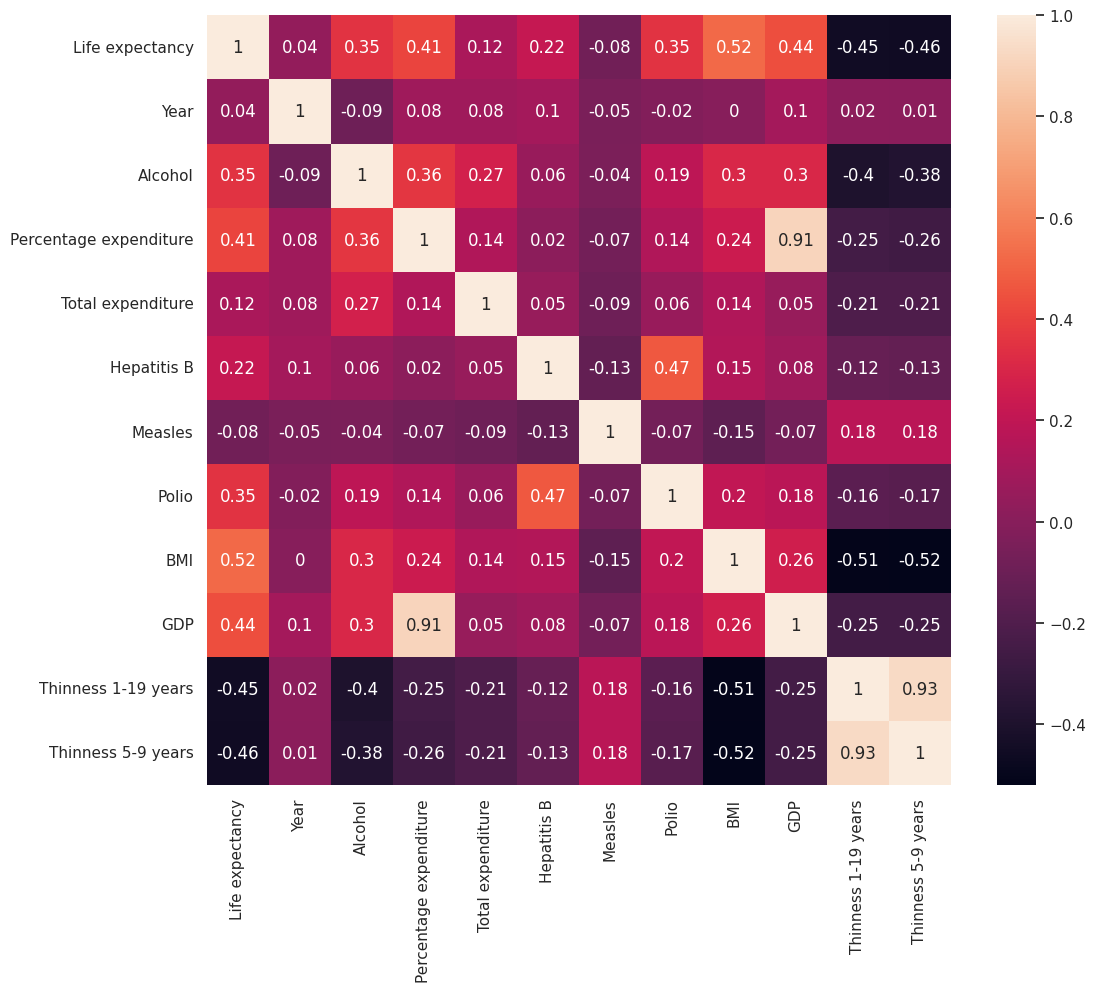

In [50]:
sns.set(rc={'figure.figsize':(12, 10)})
correlation_matrix = life.corr().round(2)
sns.heatmap(data=correlation_matrix, annot=True)
plt.show() 

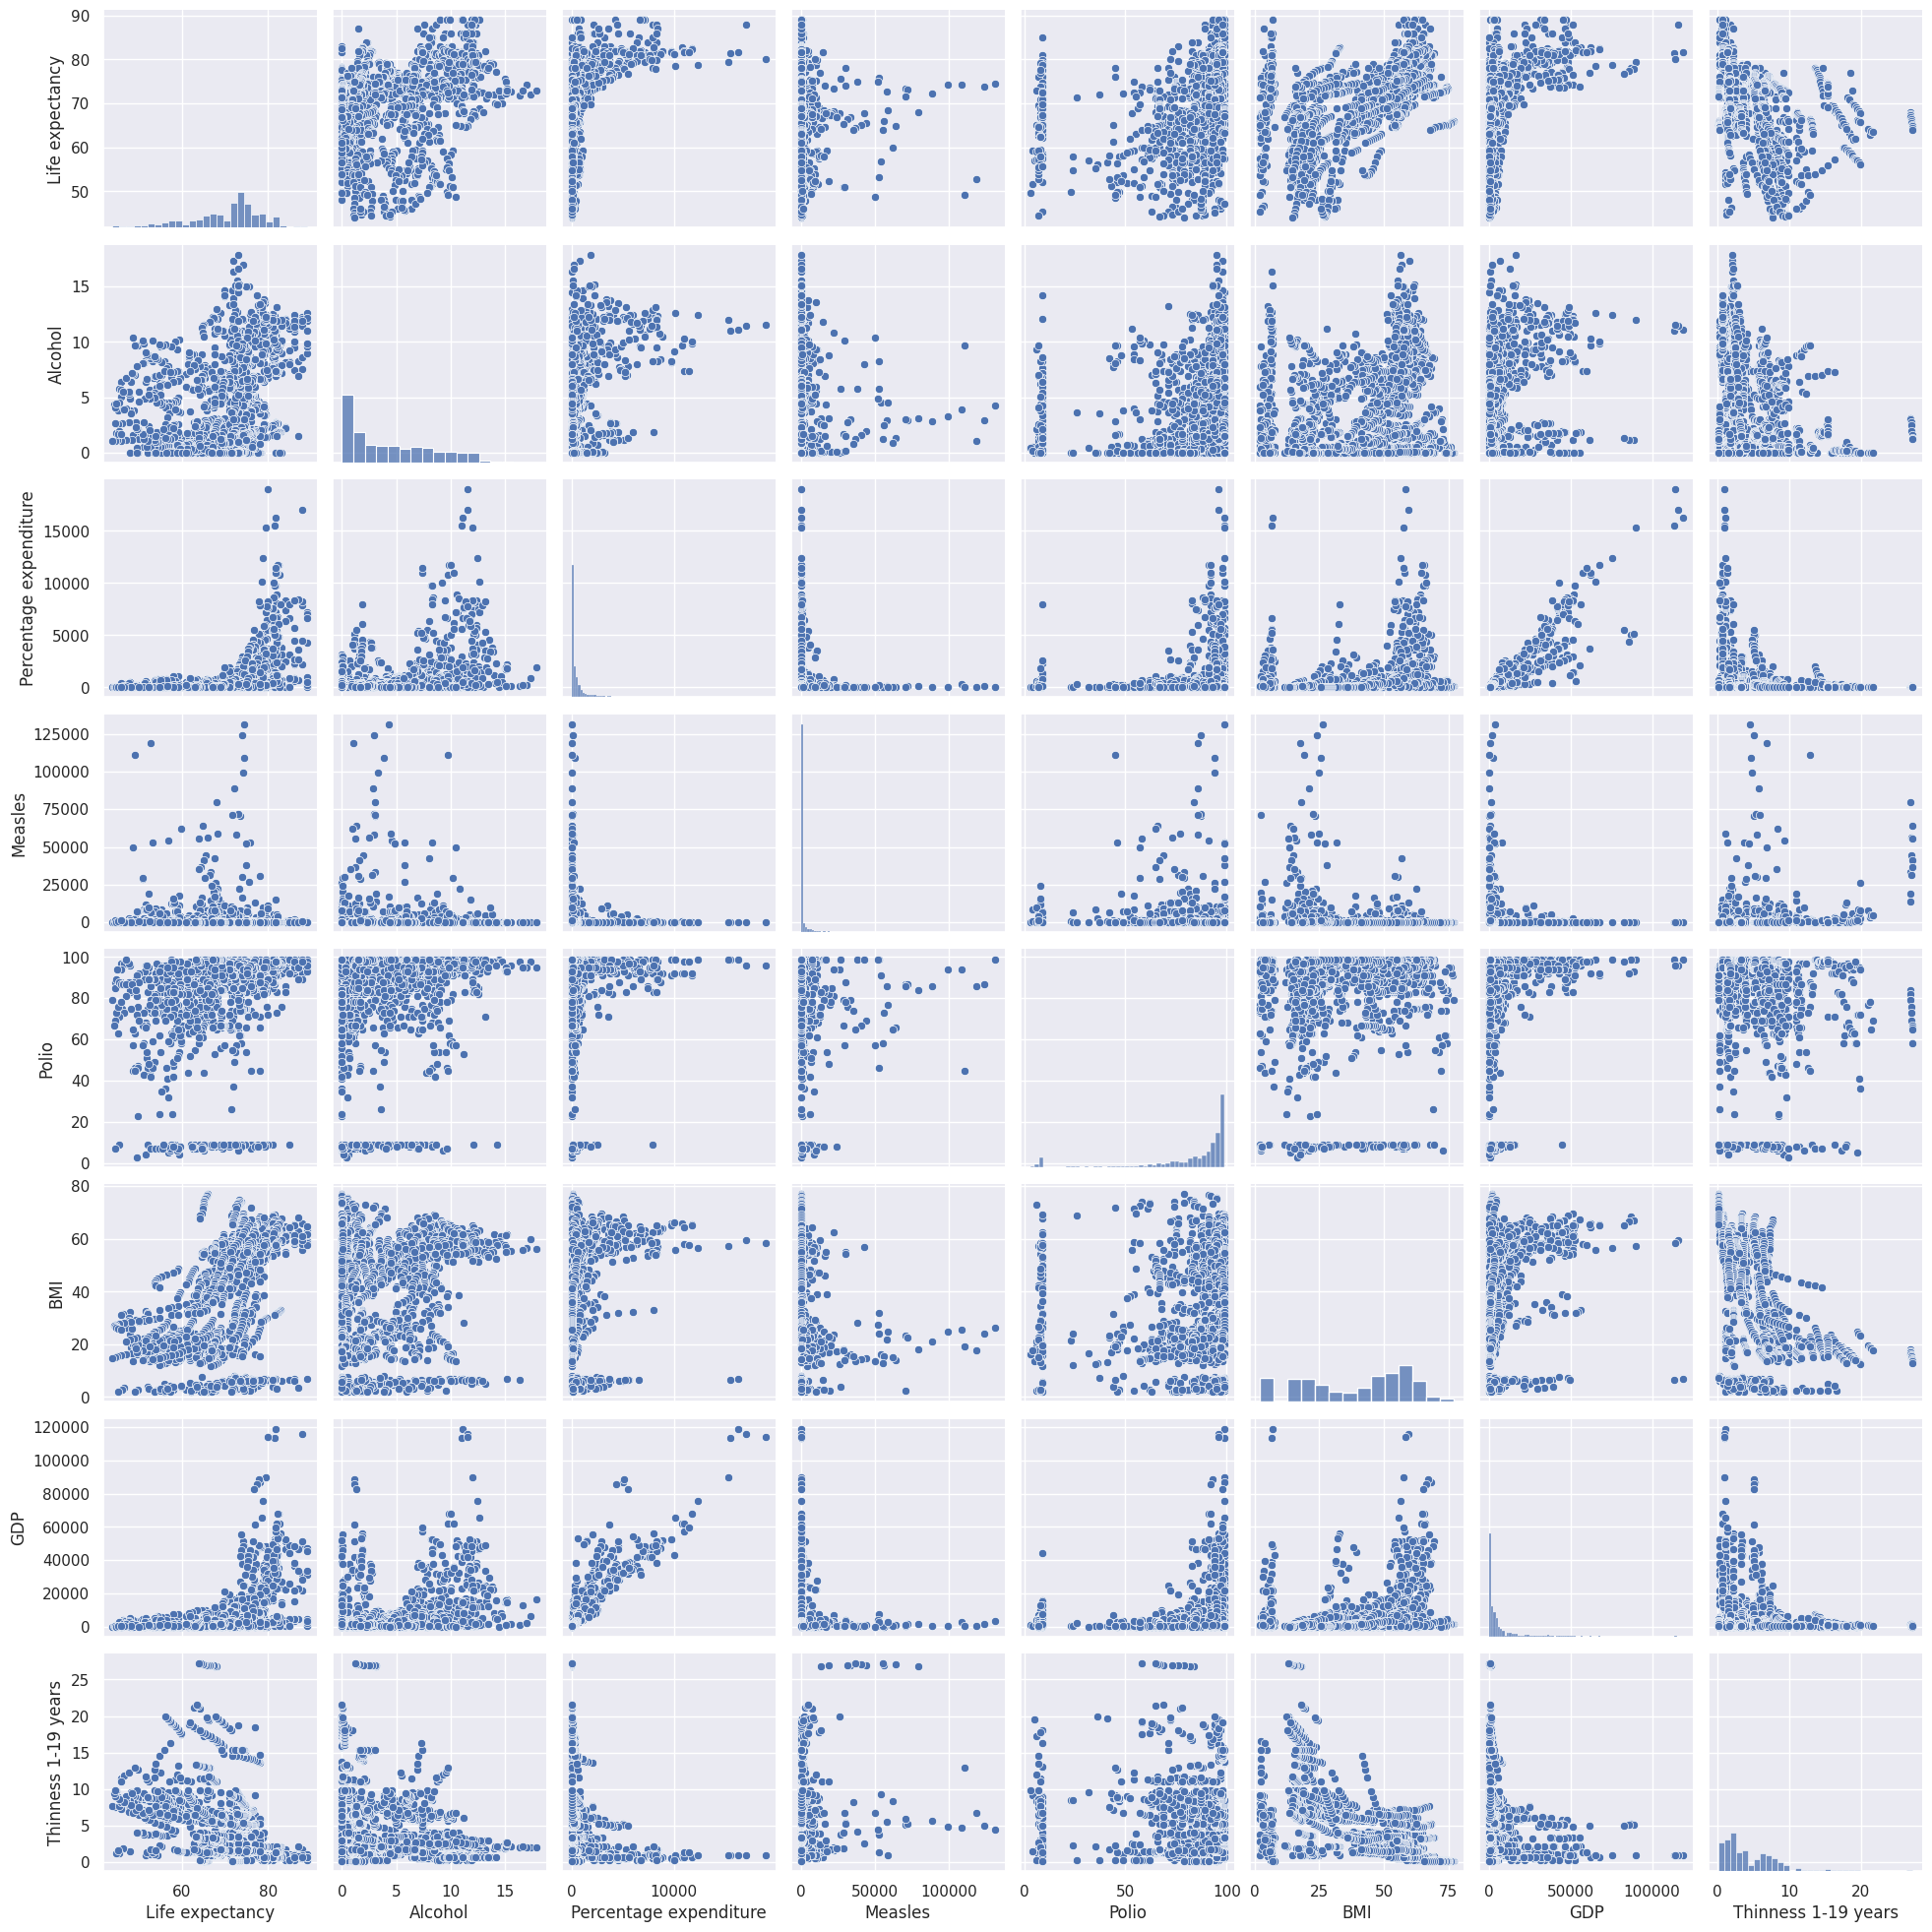

In [51]:
sns.pairplot(life[['Life expectancy', 'Alcohol', 'Percentage expenditure', 
                   'Measles', 'Polio', 'BMI', 'GDP', 'Thinness 1-19 years']])
plt.show()

In [52]:
X = life[['Alcohol', 'Percentage expenditure', 
        'Polio', 'BMI', 'GDP', 'Thinness 1-19 years']]
y = life['Life expectancy']

print(X)
print(y)

      Alcohol  Percentage expenditure  Polio   BMI         GDP  \
0        0.01               71.279624    6.0  19.1  584.259210   
1        0.01               73.523582   58.0  18.6  612.696514   
2        0.01               73.219243   62.0  18.1  631.744976   
3        0.01               78.184215   67.0  17.6  669.959000   
4        0.01                7.097109   68.0  17.2   63.537231   
...       ...                     ...    ...   ...         ...   
2933     4.36                0.000000   67.0  27.1  454.366654   
2934     4.06                0.000000    7.0  26.7  453.351155   
2935     4.43                0.000000   73.0  26.3   57.348340   
2936     1.72                0.000000   76.0  25.9  548.587312   
2937     1.68                0.000000   78.0  25.5  547.358878   

      Thinness 1-19 years  
0                    17.2  
1                    17.5  
2                    17.7  
3                    17.9  
4                    18.2  
...                   ...  
2933       

In [53]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [54]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


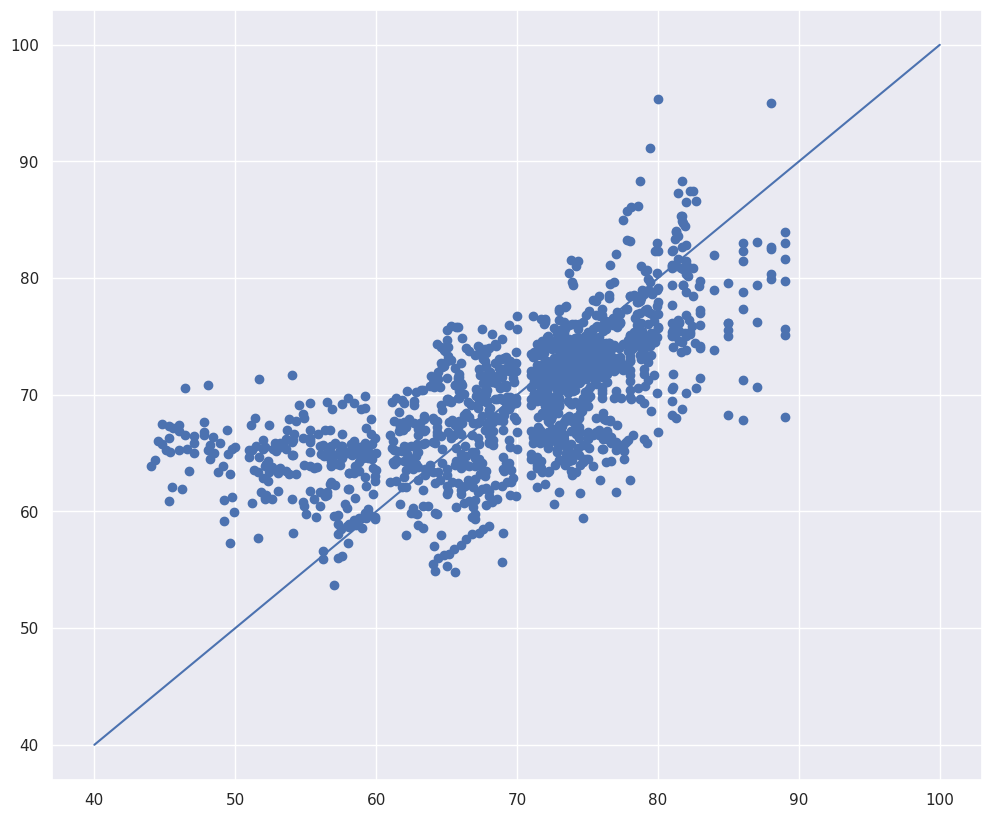

In [55]:
y_hat_train = lin_model.predict(x_train)
plt.scatter(y_train, y_hat_train)
xy_range = [40,100]
plt.plot(xy_range, xy_range)

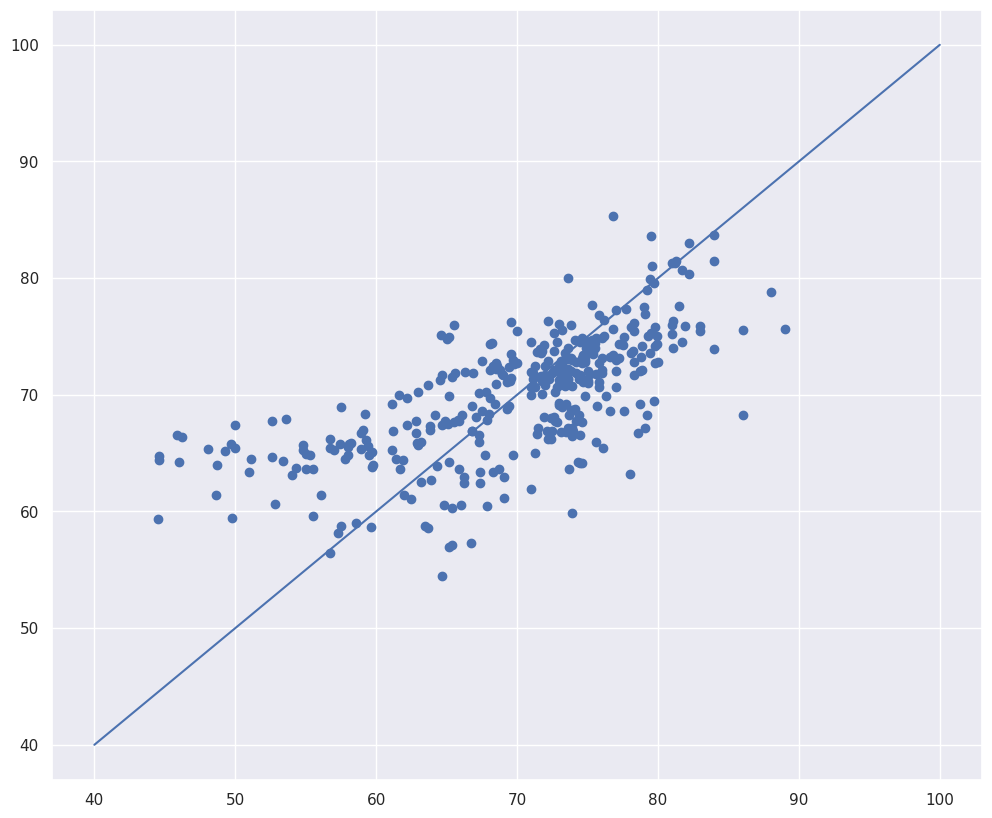

In [56]:
y_hat_test = lin_model.predict(x_test)

plt.scatter(y_test, y_hat_test)
plt.plot(xy_range, xy_range)

In [57]:
from sklearn.metrics import mean_squared_error
print('Mean Squared Error:', mean_squared_error(y_test, y_hat_test))

Mean Squared Error: 39.641918381543945


In [58]:
from sklearn.preprocessing import normalize

n_X = normalize(X, axis=0)

In [59]:
nXtrain, nXtest, y_train, y_test = train_test_split(n_X, y, test_size=0.2)
lin_model.fit(nXtrain, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


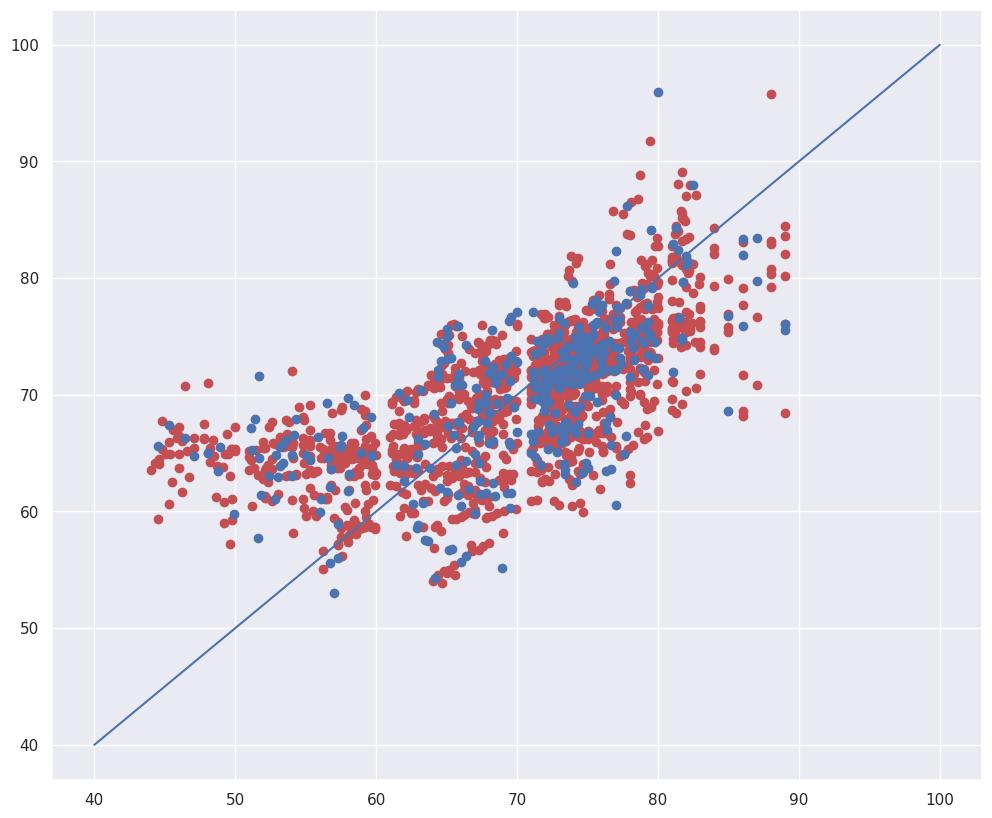

In [60]:
y_hat_train = lin_model.predict(nXtrain)
y_hat_test = lin_model.predict(nXtest)
plt.scatter(y_train, y_hat_train, color='r')
plt.scatter(y_test, y_hat_test, color='b')
plt.plot(xy_range, xy_range)

In [ ]:
y_hat_train = lin_model.predict(nXtrain)
y_hat_test = lin_model.predict(nXtest)
plt.scatter(y_train, y_hat_train, color='r')
plt.scatter(y_test, y_hat_test, color='b')
plt.plot(xy_range, xy_range)

In [61]:
from sklearn.metrics import mean_squared_error
print('Mean Squared Error:', mean_squared_error(y_test, y_hat_test))

Mean Squared Error: 43.41746176776173


(array([[1744.,  109.,    0.,    0.,    0.],
        [1757.,   63.,   24.,    4.,    5.],
        [1853.,    0.,    0.,    0.,    0.],
        [1853.,    0.,    0.,    0.,    0.],
        [1727.,  109.,   10.,    5.,    2.],
        [1740.,  102.,   11.,    0.,    0.]]),
 array([0.        , 0.04591209, 0.09182417, 0.13773626, 0.18364835,
        0.22956043]),
 <a list of 6 BarContainer objects>)

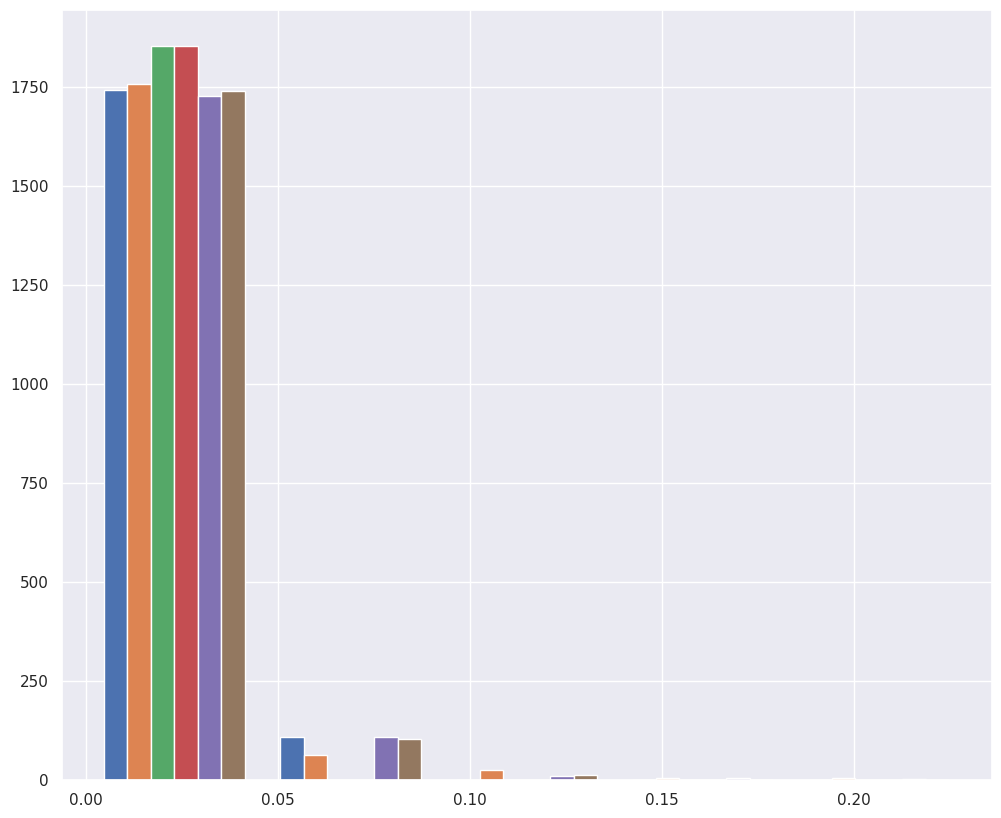

In [63]:
plt.hist(n_X, bins=5)